# Deep Learning with Python - 3th ed.
Francois Chollet
Matthew Watson


<img src="../pics/cover_DeepLearning.jpg" width=400> 

https://github.com/fchollet/deep-learning-with-python-notebooks

https://github.com/cr2003/BK_DeepLearning_with_Python_3ed



<a href="file:///C:/Users/crodr/OneDrive/InterChange/Books/Tech/DeepLearnig/Deep Learning with Python, Third Edition (François Chollet, Matthew Watson) (z-library.sk, 1lib.sk, z-lib.sk).pdf" target="_blank">Abrir PDF Local</a>

In [3]:
import os

# Definimos la ruta de tu libro
ruta_libro = r"C:\Users\crodr\OneDrive\InterChange\Books\Tech\DeepLearnig\Deep Learning with Python, Third Edition (François Chollet, Matthew Watson) (z-library.sk, 1lib.sk, z-lib.sk).pdf"

# Esto le dice a Windows: "Abre este archivo con el programa por defecto del sistema"
os.startfile(ruta_libro)

In [19]:
!pwd

/c/Users/crodr/BK_tech/DeepLearning/BK_DeepLearning_with_Python_3ed/ch03


In [20]:
!python --version

Python 3.12.10


# Chapter 03 - Introduction to TensorFlow, PyTorch, JAX, and Keras
## 3.6 Introduction to Keras

### 3.6.1 First steps with Keras
page 91

<img src="../pics/fig_3_4.png" width=800> 


The default backend for Keras right now is TensorFlow, so if you run import keras in a
fresh environment, without having configured anything, you will be running on top of
TensorFlow. There are two ways to pick a different backend:

* Set the environment variable `KERAS_BACKEND`. Before you start your python repl,
you can run the following shell command to use JAX as your Keras backend:
export `KERAS_BACKEND=jax`. Alternatively, you can add the following code snippet
at the top of your Python file or notebook (note that it must imperatively go
before the first import keras):

In [ ]:
import os

os.environ["KERAS_BACKEND"] = (
    "jax"  # Sets the environment variale from within the Python runtime
)

import keras  # Only then should you import Kers

* Edit your local Keras configuration file at `~/.keras/keras.json`. If you have
already imported Keras once, this file has already been created with default settings.
You can use any text editor to open and modify it—it’s a human-readable
JSON file. It should look like this:

```python
{
    "floatx": "float32",                    # Default floating-point precision. It should typically not be changed
    "epsilon": 1e-07,                       # Default numerical fuzzing factor. It should typically not be changed
    "backend": "tensorflow",                # Change "tensorflow" to "jax" or "torch"
    "image_data_format": "channels_last"    # This is the default image layout
}
```

### 3.6.2 Layers: The building blocks of deep learning

The fundamental data structure in neural networks is the `layer`, to which you were
introduced in chapter 2. A layer is a data processing module that takes as input one or
more tensors and that outputs one or more tensors. Some layers are stateless, but more
frequently layers have a state: the layer’s `weights`, one or several tensors learned with stochastic
gradient descent, which together contain the network’s `knowledge`.

Different types of layers are appropriate for different tensor formats and different
types of data processing. For instance, simple vector data, stored in 2D tensors of shape
(`samples, features`), is often processed by `densely connected` layers, also called `fully connected`
or `dense layers` (the `Dense` class in Keras). Sequence data, stored in 3D tensors of
shape (`samples, timesteps, features`), is typically processed by `recurrent` layers, such as
an LSTM layer, or 1D convolution layers (`Conv1D`). Image data, stored in rank-4 tensors,
is usually processed by 2D convolution layers (`Conv2D`).

You can think of layers as the LEGO bricks of deep learning, a metaphor that is made
explicit by Keras. Building deep learning models in Keras is done by clipping together
compatible layers to form useful data transformation pipelines.

#### The base Layer class in Keras

A simple API should have a single abstraction around which everything is centered.
In Keras, that’s the `Layer` class. Everything in Keras is either a `Layer` or something that
closely interacts with a `Layer`.

A `Layer` is an object that encapsulates some state (weights) and some computation (a
forward pass). The weights are typically defined in a `build()` (although they could also
be created in the constructor `__init__()`), and the computation is defined in the `call()`
method.

In the previous chapter, we implemented a `NaiveDense` class that contained two
weights `W` and `b` and applied the computation `output = activation(matmul(input, W) +b)`. 

The following is what the same layer would look like in Keras.

In [ ]:
import keras


class SimpleDense(keras.Layer):  # All Keras layer inherit from the base Layer class
    def __init__(self, units, activation=None):
        super().__init__()
        self.units = units
        self.activation = activation

    def build(self, input_shape):  # Weight creation takes place in the build() method
        batch_dim, input_dim = input_shape

        # add_weight is a shortcut method for creating weights. It's also possible to create
        # standalone variables and assign them as layer
        # attributes, like self.W = keras.Variable(shape=..., initializer=...)
        self.W = self.add_weight(
            shape=(input_dim, self.units), initializer="random_normal"
        )
        self.b = self.add_weight(shape=(self.units,), initializer="zeros")

    def call(self, inputs):
        # We define the forward pass computation in the call() method
        y = keras.ops.matmul(inputs, self.W) + self.b
        if self.activation is not None:
            y = self.activation(y)
        return y


In [ ]:
# Instantiates our layer, defined previously
my_dense = SimpleDense(units=32, activation=keras.ops.relu)

# Creates some test inputs
input_tensor = keras.ops.ones(shape=(2, 784))

# Calls the layer on the inputs, just like a function
output_tensor = my_dense(input_tensor)
print(output_tensor.shape)

(2, 32)


Now, you’re probably wondering, why did we have to implement `call()` and `build()`,
since we ended up using our layer by plainly calling it, that is to say, by using its
__call__() method? It’s because we want to be able to create the state just in time. Let’s
see how that works.

#### Automatic shape inference: Building layers on the fly
Just like with LEGO bricks, you can only “clip” together layers that are compatible. The
notion of layer compatibility here refers specifically to the fact that every layer will only
accept input tensors of a certain shape and will return output tensors of a certain
shape. Consider the following example:

In [ ]:
from keras import layers

layer = layers.Dense(32, activation="relu")  # A dense layer with 32 output units

This layer will return a tensor whose non-batch dimension is 32. It can only be connected
to a downstream layer that expects 32-dimensional vectors as its input.

When using Keras, you don’t have to worry about size compatibility most of the time
because the layers you add to your models are dynamically built to match the shape of
the incoming inputs. For instance, suppose you write the following:

In [9]:
from keras import models
from keras import layers

model = models.Sequential(
    [
        layers.Dense(32, activation="relu"),
        layers.Dense(32),
    ]
)

The layers didn’t receive any information about the shape of their inputs. Instead, they
automatically inferred their input shape as being the shape of the first inputs they see.

In the toy version of a Dense layer that we’ve implemented in chapter 2, we had to
pass the layer’s input size explicitly to the constructor in order to be able to create its
weights. That’s not ideal, because it would lead to models that look like this, where each
new layer needs to be made aware of the shape of the layer before it:

```python
    model = NaiveSequential(
    [
        NaiveDense(input_size=784, output_size=32, activation="relu"),
        NaiveDense(input_size=32, output_size=64, activation="relu"),
        NaiveDense(input_size=64, output_size=32, activation="relu"),
        NaiveDense(input_size=32, output_size=10, activation="softmax"),
    ]
)
```

It would be even worse when the rules used by a layer to produce its output shape are
complex. For instance, what if our layer returned outputs of shape 
`(batch, input_size * 2 if input_size % 2 == 0 else input_size * 3)`?

If we were to reimplement our NaiveDense layer as a Keras layer capable of automatic
shape inference, it would look like the SimpleDense layer, with its` build()` and `call()`
methods.

In the Keras `SimpleDense`, we no longer create weights in the constructor like in
the previous example. Instead, we create them in a dedicated state-creation method
`build()`, which receives as argument the first input shape seen by the layer. The `build()`
method is called automatically the first time the layer is called (via its `__call__()`
method). In fact, that’s why we defined the computation in a separate `call()` method
rather than in the `__call__()` method directly! The +  method of the base layer
schematically looks like this:

In [11]:
def __call__(self, input):
    if not self.built:
        self.build(inputs.shape)
        self.built = True
    return self.call(inputs)

With automatic shape inference, our previous example becomes simple and neat:

In [13]:
model = keras.Sequential(
    [
        SimpleDense(32, activation="relu"),
        SimpleDense(64, activation="relu"),
        SimpleDense(32, activation="relu"),
        SimpleDense(10, activation="softmax"),
    ]
)

Note that automatic shape inference is not the only thing that the Layer class’s
`__call__()` method handles. It takes care of many more things, in particular routing
between eager and graph execution, and input masking (which we cover in chapter 14).
For now, just remember: when implementing your own layers, put the forward pass in
the `call()` method.

### The “compile” step: Configuring the learning process

Once the model architecture is defined, you still have to choose three more things:

* `Loss function` (objective function)—The quantity that will be minimized during
training. It represents a measure of success for the task at hand.

* `Optimizer`—Determines how the network will be updated based on the loss function.
It implements a specific variant of stochastic gradient descent (`SGD`).

* `Metrics`—The measures of success you want to monitor during training
and validation, such as classification accuracy. Unlike the loss, training will
not optimize directly for these metrics. As such, metrics don’t need to be
differentiable.

Once you’ve picked your `loss`, `optimizer`, and `metrics`, you can use the built-in `compile()`
and `fit()` methods to start training your model. Alternatively, you can write your own
custom training loops—we cover how to do this in chapter 7. It’s a lot more work! For
now, let’s take a look at `compile()` and `fit()`.

The `compile()` method configures the training process—you’ve already been introduced
to it in your very first neural network example in chapter 2. It takes the arguments
`optimizer`, `loss`, and `metrics` (a list):

In [ ]:
# Defines a linear classifier
model = keras.Sequential([keras.layers.Dense(1)])

model.compile(
    optimizer="rmsprop",  # Specifies the optimizer by name: RMSprop (it's case-insensitive)
    loss="mean_squared_error",  # Specifies the loss by name: mean squared error
    metrics=["accuracy"],  # Specifies a list of metrics: in this case, only accuracy
)

In the previous call to `compile()`, we passed the `optimizer`, `loss`, and `metrics` as strings
(such as "`rmsprop`"). These strings are actually shortcuts that get converted to Python
objects. For instance, "`rmsprop`" becomes `keras.optimizers.RMSprop()`. Importantly,
it’s also possible to specify these arguments as object instances, like this:

```python
    model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-4),
    loss=my_custom_loss,
    metrics=[my_custom_metric_1, my_custom_metric_2],
)
```

Previously, like we did in 3.3.2 we must create the synthetic data:

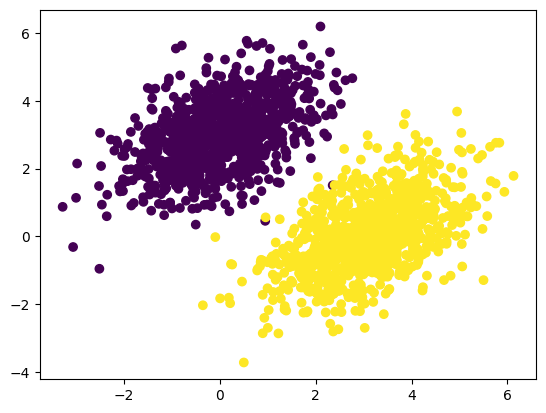

In [21]:
import numpy as np

num_samples_per_class = 1_000

# Generates the first class of points: 1_000 random 2D points with specified "mean" and "covariance" matrix.
# Intuitively, the "covariance matrix" describes the shape of the point cloud, and the "mean" describes its
# position in the plan.cov=[[1, 0.5], [0.5, 1]] corrresponds to "an oval-like point cloud oriented from bottom
# left to top right."
negative_samples = np.random.multivariate_normal(
    mean=[0, 3], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)

# Generates the other class of points with a different mean and the same covariance matrix (point cloud with a
# different poistion and the same shape)
positive_samples = np.random.multivariate_normal(
    mean=[3, 0], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)

inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)
inputs.shape

targets = np.vstack(
    (
        np.zeros((num_samples_per_class, 1), dtype="float32"),
        np.ones((num_samples_per_class, 1), dtype="float32"),
    )
)

import matplotlib.pyplot as plt

plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0])
plt.show()

### 3.6.6 Understanding the fit method

After `compile()` comes `fit()`. The `fit` method implements the training loop itself. Its
key arguments are

* The `data` (inputs and targets) to train on. It will typically be passed either in the
form of NumPy arrays or a TensorFlow `Dataset` object. You’ll learn more about
the `Dataset` API in the next chapters.

* The number of `epochs` to train for: how many times the training loop should iterate
over the data passed.

* The `batch size` to use within each `epoch` of `mini-batch gradient descent`: the number
of training examples considered to compute the gradients for one weight
update step.

```python
    history = model.fit(
    inputs,  # The input examples, as a NumPy array
    targets,  # The corresponding training targets, as NumPy array
    epochs=5,  # The training loop will iterate over the data 5 times
    batch_size=128,  # The training loop will iterate over the data in batches of 128 examples
)
```

The call to fit returns a `History` object. This object contains a `history` field, which is a
dict mapping key, such as "`loss`" or specific metric names to the list of their per-epoch
values:

```python
    >>> history.history
{"binary_accuracy": [0.855, 0.9565, 0.9555, 0.95, 0.951],
"loss": [0.6573270302042366,
0.07434618508815766,
0.07687718723714351,
0.07412414988875389,
0.07617757616937161]}
```

### 3.6.7 Monitoring loss and metrics on validation data

The goal of machine learning is not to obtain models that perform well on the training
data, which is easy—all you have to do is follow the gradient. The goal is to obtain
models that perform well in general, particularly on data points that the model has
never encountered before. Just because a model performs well on its training data
doesn’t mean it will perform well on data it has never seen! For instance, it’s possible
that your model could end up merely memorizing a mapping between your training
samples and their targets, which would be useless for the task of predicting targets for
data the model has never seen before. We’ll go over this point in much more detail in
the chapter 5.

To keep an eye on how the model does on new data, it’s standard practice to reserve
a subset of the training data as “validation data”: you won’t be training the model on
this data, but you will use it to compute a loss value and metrics value. You do this by
using the `validation_data` argument in `fit()`. Like the training data, the validation
data could be passed as NumPy arrays or as a TensorFlow `Dataset` object.

In [ ]:
# Using the validation data argument

model = keras.Sequential([keras.layers.Dense(1)])
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.1),
    loss=keras.losses.MeanSquaredError(),
    metrics=[keras.metrics.BinaryAccuracy()],
)

# To avoid having samples from only one class in the validation data,
# shuffles the inputs and targets using a random indices permutation
indices_permutation = np.random.permutation(len(inputs))
shuffled_inputs = inputs[indices_permutation]
shuffled_targets = targets[indices_permutation]

# Reserve 30% of the training inputs and targets for "validation".
# (We'll exlude these samples from training and reserve them to
# compute the "validation loss" and metrics)
num_validation_samples = int(0.3 * len(inputs))
val_inputs = shuffled_inputs[:num_validation_samples]
val_targets = shuffled_targets[:num_validation_samples]
training_inputs = shuffled_inputs[num_validation_samples:]
training_targets = shuffled_targets[num_validation_samples:]

model.fit(
    # Training data, used to update the weights of the model
    training_inputs,
    training_targets,
    epochs=5,
    batch_size=16,
    # validation data, used only to monitor the "validation loss" and metrics
    validation_data=(val_inputs, val_targets),
)


Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.9336 - loss: 0.2661 - val_binary_accuracy: 0.8183 - val_loss: 0.1335
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 896us/step - binary_accuracy: 0.9529 - loss: 0.0714 - val_binary_accuracy: 0.9117 - val_loss: 0.2214
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 906us/step - binary_accuracy: 0.9579 - loss: 0.0759 - val_binary_accuracy: 0.9850 - val_loss: 0.0490
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.9536 - loss: 0.0749 - val_binary_accuracy: 0.9983 - val_loss: 0.0453
Epoch 5/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.9507 - loss: 0.0774 - val_binary_accuracy: 0.9983 - val_loss: 0.0300


The value of the loss on the validation data is called the `validation loss`, to distinguish it
from the `training loss`. Note that it’s essential to keep the training data and validation
data strictly separate: the purpose of validation is to monitor whether what the model
is learning is actually useful on new data. If any of the validation data has been seen by
the model during training, your validation loss and metrics will be flawed.

If you want to compute the validation loss and metrics after training is complete, you
can call the `evaluate` method:

In [23]:
loss_and_metrics = model.evaluate(val_inputs, val_targets, batch_size=128)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - binary_accuracy: 0.9983 - loss: 0.0300


`evaluate()` will iterate in batches (of size `batch_size`) over the data passed and return
a list of scalars, where the first entry is the validation loss and the following entries are
the validation metrics. If the model has no metrics, only the validation loss is returned
(rather than a list).

### 3.6.8 Inference: Using a model after training

Once you’ve trained your model, you’re going to want to use it to make predictions
on new data. This is called inference. To do this, a naive approach would simply be to
`__call__()` the model:

```python
    # Takes a NumPy array or a tensor for your current backend and returns
    # a tensor for your current backend
    predictions = model(new_inputs)
```

However, this will process all inputs in new_inputs at once, which may not be feasible
if you’re looking at a lot of data (in particular, it may require more memory than your
GPU has).
A better way to do inference is to use the `predict()` method. It will iterate over the
data in small batches and return a NumPy array of predictions. And unlike `__call__()`, it
can also process TensorFlow `Dataset` objects:

```python
    # Takes a NumPy array or a Dataset and returns a NumPy array
    predictions = model(new_inputs)
```

For instance, if we use `predict()` on some of our validation data with the linear model
we trained earlier, we get scalar scores that correspond to the model’s prediction for
each input sample:

In [25]:
predictions = model.predict(val_inputs, batch_size=128)
print(predictions[:10])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
[[ 0.63350767]
 [ 0.00408155]
 [-0.18133113]
 [ 0.7789911 ]
 [-0.07287344]
 [ 0.09220353]
 [ 0.72731644]
 [ 1.0696937 ]
 [ 0.09982821]
 [ 0.76430446]]


#### Display the Results

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


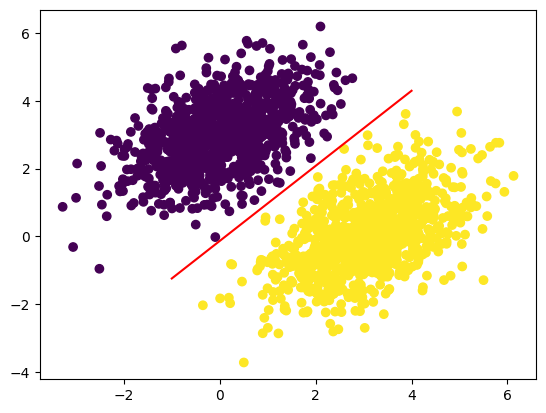

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

predictions = model.predict(inputs, batch_size=128)

# Extract W and b from the Dense layer
W = model.layers[0].get_weights()[0]  # shape (2, 1)
b = model.layers[0].get_weights()[1]  # shape (1,)

# Plot: color points + decision line
x = np.linspace(-1, 4, 100)
y = -W[0] / W[1] * x + (0.5 - b) / W[1]

plt.plot(x, y, "-r")
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()